# Shor's Algorithm
Shor's algorithm factors $N$ by turning factoring into *period-finding*: pick a random $a$ coprime to $N$, and the sequence
$a^x \bmod N$ is periodic with some period $r$. Once you know $r$ (and it's even), $\gcd(a^{r/2}\pm 1, N)$ hands you the factors
with high probability — pure classical number theory.
Finding $r$ quantumly is exactly QPE from the last notebook, with $U|y\rangle=|ay \bmod N\rangle$ as the unitary being estimated.
We factor $N=15$ with $a=7$ (so $r=4$, matching `math_shor.md`), then decode the measurement with continued fractions.
Runs on the local Aer simulator (noiseless).

In [34]:
# Inverse QFT, same helper as the QPE notebook
from math import pi
from qiskit import QuantumCircuit

def iqft(n: int) -> QuantumCircuit:
    qc = QuantumCircuit(n)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    for k in range(n):
        for q in range(k):
            qc.cp(-pi / 2 ** (k - q), q, k)
        qc.h(k)
    return qc

In [35]:
# Controlled multiplication-by-a mod 15: a permutation of the 4-qubit target register, implemented with swaps
# (+ a bit-flip for a in {7,11,13}). The permutation's cycle order always divides 4 here, so U^power == U^(power % 4);
# building 'power' raw repetitions instead (up to 128 for the last counting qubit) blows the transpiled circuit up
# to >13,000 two-qubit gates for no mathematical reason, which is exactly what turns the hardware histogram to noise.
def c_amod15(a: int, power: int):
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("'a' must be 2, 4, 7, 8, 11 or 13")
    power %= 4
    U = QuantumCircuit(4)
    for _ in range(power):
        if a in [2, 13]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a in [7, 8]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [4, 11]:
            U.swap(1, 3)
            U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    return U.control()

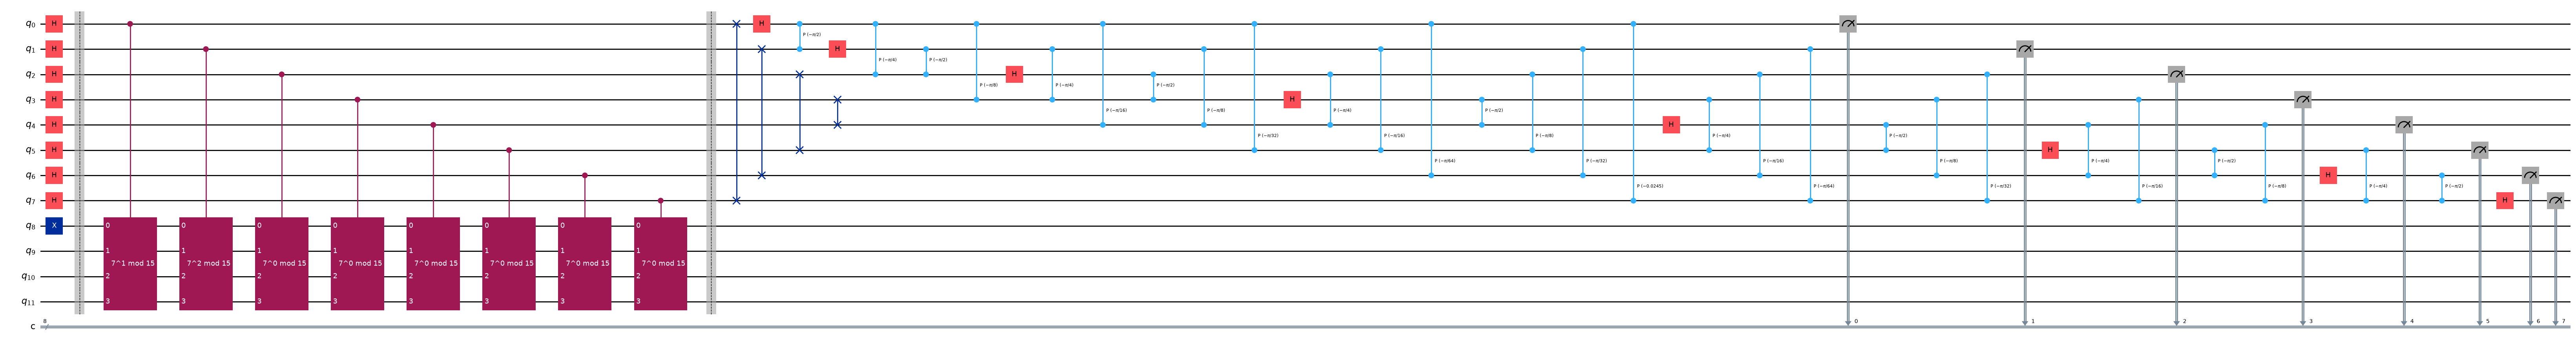

In [36]:
# Order-finding circuit: n_count counting qubits + 4-qubit target register prepared in the eigenvector |1>
N = 15
a = 7                                         # coprime to 15; true order r=4 (see math_shor.md)
n_count = 8                                   # 2**n_count >> N**2 for a clean continued-fractions readout

counting = list(range(n_count))
target = list(range(n_count, n_count + 4))

qc = QuantumCircuit(n_count + 4, n_count)
qc.h(counting)                                # superposition over every possible exponent x
qc.x(target[0])                               # prepare the eigenvector |1>
qc.barrier()
for q in counting:
    qc.append(c_amod15(a, 2 ** q), [q] + target)   # controlled-U^(2^q): phase kickback of the period info
qc.barrier()
qc.compose(iqft(n_count), counting, inplace=True)  # decode the periodic phases into a binary estimate
qc.measure(counting, counting)

qc.draw("mpl", fold=-1)

In [ ]:
# Run on the Aer simulator (transpile first so the custom modular-mult gate is decomposed)
from qiskit import transpile
from qiskit_aer import AerSimulator

sim = AerSimulator()
counts = sim.run(transpile(qc, sim), shots=4096).result().get_counts()

In [ ]:
# Classical post-processing: turn each measured bitstring into a candidate period r via continued fractions
from fractions import Fraction
from math import gcd
from qiskit.visualization import plot_histogram

def guess_order(counts: dict) -> int | None:
    for bitstring, _ in sorted(counts.items(), key=lambda kv: -kv[1]):
        phase = int(bitstring, 2) / 2 ** n_count
        r = Fraction(phase).limit_denominator(N).denominator
        if r <= 1 or pow(a, r, N) != 1:
            continue
        # shrink to the smallest divisor of r that still satisfies a^d = 1 mod N
        return next(d for d in range(1, r + 1) if r % d == 0 and pow(a, d, N) == 1)
    return None

r = guess_order(counts)
print("order r :", r)
plot_histogram(counts)

In [ ]:
# Turn the period r into the actual factors of N
def factor_from_order(r: int) -> tuple[int, int] | None:
    if r is None or r % 2 != 0:
        return None
    p = gcd(pow(a, r // 2, N) - 1, N)
    q = gcd(pow(a, r // 2, N) + 1, N)
    return (p, q) if p * q == N else None

print("factors :", factor_from_order(r))

## What the results mean

**Four peaks, not one.** Unlike the QPE notebook's single-phase example, order-finding produces a superposition over *every* multiple of $1/r$: measuring the counting register lands on $m/2^n \approx k/r$ for a uniformly random $k \in \{0,1,\dots,r-1\}$. With $r=4$ that's peaks near $0, \tfrac14, \tfrac12, \tfrac34$ — i.e. bitstrings whose integer value is close to $0, 64, 128, 192$ out of $2^8=256$. Continued fractions turns each ratio back into a small denominator; we keep the first candidate that actually satisfies $a^r \equiv 1 \pmod N$ (the $k=0$ peak is a false positive to filter out, since it gives $r=1$).

**Why this is the crown jewel.** Every earlier notebook was a warm-up for this move: Deutsch-Jozsa and Simon showed superposition can hide a global structure in phases; QFT/QPE showed how to read a hidden phase back out. Shor's algorithm just points that same machine at $U|y\rangle=|ay\bmod N\rangle$, and out falls the period that classical computers need sub-exponential-but-still-huge effort to find. That period is the entire security assumption behind RSA.

**Keeping the circuit shallow.** Watch the multiplication power: `c_amod15` reduces it mod 4 before building gates, because the swap-permutation here has a cycle order dividing 4, so `U^128` is mathematically identical to `U^0`. Skipping that reduction (building 128 raw repetitions of the swap block for the last counting qubit) inflates the transpiled circuit to over 13,000 two-qubit gates — which on real hardware would collapse the output into near-uniform noise across all 256 bitstrings instead of four clean spikes. On the noiseless simulator the four peaks dominate and the factors come out as `(3, 5)`.

**The period-aliasing guard.** Noise (or an unlucky continued-fractions round) can land the top bitstring on a *multiple* of the true period rather than the period itself — e.g. decoding to `r=8` when the actual order is `r=4`. The check `a^r ≡ 1 mod N` alone doesn't catch this, because if `a^4=1` then `a^8=1` too; using the non-minimal `r=8` in `gcd(a^{r/2}±1, N)` computes `gcd(a^4-1, N) = gcd(0, N) = N`, producing the degenerate `(N, 1)` "factorization" instead of the real one. `guess_order` guards against this by shrinking to the *smallest* divisor of `r` that still satisfies `a^d ≡ 1 mod N`.